**NOTE: Bolides 2, 8, 12, 13, and 14 have been removed from calculation due to the data quality.**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from ast import literal_eval

In [2]:
bd= pd.read_csv('datafixed_bolide_data.csv') #the index for bolide 1 is 12

In [3]:
def findtheta(lat, long, alt): #kept here but not actually used in calculations
    x= np.abs(lat[-1]-lat[0])*0.0175
    y= np.abs(long[-1]-long[0])*0.0175
    z= np.abs(alt[-1]-alt[0])
    return np.arctan((np.sqrt(x**2+y**2))/z)

def degtom (lat1, long1, lat2, long2, r= 6371000): #haversine equation
    lat1rad = np.radians(lat1) #conversion to radians since our measurements are in degrees
    long1rad = np.radians(long1)
    lat2rad = np.radians(lat2)
    long2rad = np.radians(long2)
    dlat = lat2rad - lat1rad #the difference in latitude
    dlong = long2rad - long1rad #the difference in longitude

    a= np.sin(dlat/2)**2 + np.cos(lat1rad)*np.cos(lat2rad)*np.sin(dlong/2)**2 #direct calculation broken into parts
    b= 2*np.arcsin(np.sqrt(a))

    #uncertainty estimation on degtom, each of these 4 lines is representitive of a partial derivitave with respect to that variable 
    errorla1= -r*2*(np.sin(lat1rad)*np.cos(lat2rad)*np.sin(dlong/2)**2+np.cos(dlat/2)*np.sin(dlat/2))/(np.sqrt(1-(np.cos(lat1rad)*np.cos(lat2rad)*np.sin(dlong/2)**2+np.sin(dlat/2)**2)**2))
    errorla2= r*2*(np.cos(dlat/2)*np.sin(dlat/2)-np.cos(lat1rad)*np.sin(lat2rad)*np.sin(dlong/2)**2)/(np.sqrt(1-(np.sin(dlat/2)**2+np.cos(lat1rad)*np.cos(lat2rad)*np.sin(dlong/2)**2)**2))
    errorlo1= -r*2*(np.cos(lat1rad)*np.cos(lat2rad)*np.cos(dlong/2)*np.sin(dlong/2))/(np.sqrt(1-(np.cos(lat1rad)*np.cos(lat2rad)*np.sin(dlong/2)**2+np.sin(dlat/2)**2)**2))
    errorlo2= r*2*(np.cos(lat1rad)*np.cos(lat2rad)*np.cos(dlong/2)*np.sin(dlong/2))/(np.sqrt(1-(np.cos(lat1rad)*np.cos(lat2rad)*np.sin(dlong/2)**2+np.sin(dlat/2)**2)**2))
    #this is the errors added in quadrature 
    errordegtom= np.sqrt((errorla1)**2*errorlat**2+(errorla2)**2*errorlat**2+(errorlo1)**2*errorlong**2+(errorlo2)**2*errorlong**2)
    
    
    return r*b, errordegtom

def airrho(z, H=8500): #calculates density based on rho naught, height, and scale height
    rho0= 1.225 #kg/m^3                   #8.5 km is the scale height for Earth and 1.225 kg/m^3 is the density of air at sea level
    return (rho0*(1/(np.e**(z/H))))

H=8500 #meters
rockyrho = 3500 #kg/m^3
metalrho = 7500 #kg/m^3 #constants for bolide density based on possible composition
icyrho = 750 #kg/m^3
bolidelist= [] #this will make a list of our size estimations
errorlist= [] #this will make a list of our uncertainty estimations

**BOLIDE 1**

In [4]:
b1= bd.iloc[12] #locating the bolide within the dataframe

In [5]:
lat= literal_eval(b1['lat_stereo_g16']) #reads the latitude value, this bolide was observed by the satellite GOES16
long= literal_eval(b1['lon_stereo_g16'])
alt= np.array(literal_eval(b1['alt_stereo_g16']))*1000 #conversion to meters 
energy = literal_eval(b1['energyJoules_stereo_g16'])

errorlat= 4000 #we're estimating that the error on latitude and longitude measurements are half a pixel, or 4000 meters
errorlong= 4000
erroralt= literal_eval(b1['residual_dist_stereo_g16'])

In [6]:
for i in range(len(energy)):
    if energy[i] == np.max(energy):
        imaxenergy=i #determine the index at which the bolide catastrophically destructs

In [7]:
totalmass= 0 
totalerror= 0

for i in range (imaxenergy): #until the bolide catastrophically destructs...
    deltalatlong = np.abs(degtom(lat[i], long[i], lat[i+1], long[i+1]))[0]
    
    errordeltalatlong= degtom(lat[i], long[i], lat[i+1], long[i+1])[1]
    
    deltaalt = np.abs(alt[i+1]-alt[i])

    erroralt1= (alt[i]-alt[i+1])/np.abs(alt[i+1]-alt[i]) #partial derivative
    erroralt2= (alt[i+1]-alt[i])/np.abs(alt[i]-alt[i+1])
    errordalt= np.sqrt((erroralt1)**2*(erroralt[i])**2+(erroralt2)**2*(erroralt[i+1])**2)
    
    h= np.sqrt(deltalatlong**2 + deltaalt**2) #pythagorean theorum the change in latitude, longitude, and altitude
    
    errorh= np.sqrt((deltalatlong/h)**2*(errordeltalatlong)**2+(deltaalt/h)**2*(errordalt)**2) 

    altm = (alt[i]+alt[i+1])
    
    rho = airrho((1/2)*altm)

    erroraltm= .5*np.sqrt(erroralt[i]**2+erroralt[i+1]**2)
    errorrho= (rho/8500)*erroraltm

    totalmass = totalmass+(h*rho) #sum up the total mass for each cylinder

    terho= (errorrho/rho)**2
    teh= (errorh/h)**2
    totalerror= totalerror+(h*rho*(np.sqrt(terho+teh)))**2 #and the total error for each cylinder

In [8]:
np.sqrt(totalerror) #the standard deviation on the mass measurement

250.7583513707537

In [9]:
rrocky = (3/4)*(totalmass/rockyrho)*100 #+- totalerror
rmetal = (3/4)*(totalmass/metalrho)*100
ricy = (3/4)*(totalmass/icyrho)*100
bolidelist.append(rrocky)
bolidelist.append(rmetal)
bolidelist.append(ricy)
print (rrocky, rmetal, ricy) #this unit is CM

0.003860782587333406 0.0018016985407555896 0.018016985407555895


In [10]:
errorrrocky = (3/4)*(np.sqrt(totalerror)/rockyrho)*100
errorrmetal = (3/4)*(np.sqrt(totalerror)/metalrho)*100
errorricy = (3/4)*(np.sqrt(totalerror)/icyrho)*100
errorlist.append(errorrrocky)
errorlist.append(errorrmetal)
errorlist.append(errorricy)
print (errorrrocky, errorrmetal, errorricy) #CM #the error on each radius based on their material

5.373393243659008 2.507583513707537 25.07583513707537


In [11]:
print( f'Bolide 1: Rocky bolide radius = {rrocky*100}+-{errorrrocky*100} CM. Metal bolide radius = {rmetal*100}+-{errorrmetal*100} CM. Icy bolide radius {ricy*100}+-{errorricy*100} CM.')

Bolide 1: Rocky bolide radius = 0.3860782587333406+-537.3393243659008 CM. Metal bolide radius = 0.18016985407555897+-250.75835137075367 CM. Icy bolide radius 1.8016985407555894+-2507.583513707537 CM.


**BOLIDE 3**

In [12]:
b3= bd.iloc[52]

In [13]:
lat= literal_eval(b3['lat_stereo_g16'])
long= literal_eval(b3['lon_stereo_g16'])
alt= np.array(literal_eval(b3['alt_stereo_g16']))*1000 #conversion to meters 
energy = literal_eval(b3['energyJoules_stereo_g16'])

errorlat= 4000 #meters 
errorlong= 4000
erroralt= literal_eval(b3['residual_dist_stereo_g16'])

In [14]:
for i in range(len(energy)):
    if energy[i] == np.max(energy):
        imaxenergy=i #determine the index at which the bolide catastrophically destructs

In [15]:
totalmass= 0 
totalerror= 0

for i in range (imaxenergy): #until the bolide catastrophically destructs...
    deltalatlong = np.abs(degtom(lat[i], long[i], lat[i+1], long[i+1]))[0]
    
    errordeltalatlong= degtom(lat[i], long[i], lat[i+1], long[i+1])[1]
    
    deltaalt = np.abs(alt[i+1]-alt[i])

    erroralt1= (alt[i]-alt[i+1])/np.abs(alt[i+1]-alt[i]) #partial derivative
    erroralt2= (alt[i+1]-alt[i])/np.abs(alt[i]-alt[i+1])
    errordalt= np.sqrt((erroralt1)**2*(erroralt[i])**2+(erroralt2)**2*(erroralt[i+1])**2)
    
    h= np.sqrt(deltalatlong**2 + deltaalt**2) #pythagorean theorum the change in latitude, longitude, and altitude
    
    errorh= np.sqrt((deltalatlong/h)**2*(errordeltalatlong)**2+(deltaalt/h)**2*(errordalt)**2) 

    altm = (alt[i]+alt[i+1])
    
    rho = airrho((1/2)*altm)

    erroraltm= .5*np.sqrt(erroralt[i]**2+erroralt[i+1]**2)
    errorrho= (rho/8500)*erroraltm

    totalmass = totalmass+(h*rho) #sum up the total mass for each cylinder

    terho= (errorrho/rho)**2
    teh= (errorh/h)**2
    totalerror= totalerror+(h*rho*(np.sqrt(terho+teh)))**2 #and the total error for each cylinder

In [16]:
np.sqrt(totalerror)

880.8886184259864

In [17]:
rrocky = (3/4)*(totalmass/rockyrho)*100 #+- totalerror
rmetal = (3/4)*(totalmass/metalrho)*100
ricy = (3/4)*(totalmass/icyrho)*100
bolidelist.append(rrocky)
bolidelist.append(rmetal)
bolidelist.append(ricy)
print (rrocky, rmetal, ricy) #this unit is CM

0.010168094527093807 0.004745110779310443 0.04745110779310443


In [18]:
errorrrocky = (3/4)*(np.sqrt(totalerror)/rockyrho)*100
errorrmetal = (3/4)*(np.sqrt(totalerror)/metalrho)*100
errorricy = (3/4)*(np.sqrt(totalerror)/icyrho)*100
errorlist.append(errorrrocky)
errorlist.append(errorrmetal)
errorlist.append(errorricy)
print (errorrrocky, errorrmetal, errorricy) #CM

18.876184680556847 8.808886184259864 88.08886184259863


In [19]:
print( f'Bolide 3: Rocky bolide radius = {rrocky*100}+-{errorrrocky*100} CM. Metal bolide radius = {rmetal*100}+-{errorrmetal*100} CM. Icy bolide radius {ricy*100}+-{errorricy*100} CM.')

Bolide 3: Rocky bolide radius = 1.0168094527093807+-1887.6184680556846 CM. Metal bolide radius = 0.4745110779310443+-880.8886184259864 CM. Icy bolide radius 4.745110779310443+-8808.886184259864 CM.


**BOLIDE 4**

In [20]:
b4= bd.iloc[71]

In [21]:
lat= literal_eval(b4['lat_stereo_g17'])
long= literal_eval(b4['lon_stereo_g17'])
alt= np.array(literal_eval(b4['alt_stereo_g17']))*1000 #conversion to meters 
energy = literal_eval(b4['energyJoules_stereo_g17'])

errorlat= 4000 #meters 
errorlong= 4000
erroralt= literal_eval(b4['residual_dist_stereo_g17'])

In [22]:
for i in range(len(energy)):
    if energy[i] == np.max(energy):
        imaxenergy=i #determine the index at which the bolide catastrophically destructs

In [23]:
totalmass= 0 
totalerror= 0

for i in range (imaxenergy): #until the bolide catastrophically destructs...
    deltalatlong = np.abs(degtom(lat[i], long[i], lat[i+1], long[i+1]))[0]
    
    errordeltalatlong= degtom(lat[i], long[i], lat[i+1], long[i+1])[1]
    
    deltaalt = np.abs(alt[i+1]-alt[i])

    erroralt1= (alt[i]-alt[i+1])/np.abs(alt[i+1]-alt[i]) #partial derivative
    erroralt2= (alt[i+1]-alt[i])/np.abs(alt[i]-alt[i+1])
    errordalt= np.sqrt((erroralt1)**2*(erroralt[i])**2+(erroralt2)**2*(erroralt[i+1])**2)
    
    h= np.sqrt(deltalatlong**2 + deltaalt**2) #pythagorean theorum the change in latitude, longitude, and altitude
    
    errorh= np.sqrt((deltalatlong/h)**2*(errordeltalatlong)**2+(deltaalt/h)**2*(errordalt)**2) 

    altm = (alt[i]+alt[i+1])
    
    rho = airrho((1/2)*altm)

    erroraltm= .5*np.sqrt(erroralt[i]**2+erroralt[i+1]**2)
    errorrho= (rho/8500)*erroraltm

    totalmass = totalmass+(h*rho) #sum up the total mass for each cylinder

    terho= (errorrho/rho)**2
    teh= (errorh/h)**2
    totalerror= totalerror+(h*rho*(np.sqrt(terho+teh)))**2 #and the total error for each cylinder

In [24]:
np.sqrt(totalerror)

3.565907009689328

In [25]:
rrocky = (3/4)*(totalmass/rockyrho)*100 #+- totalerror
rmetal = (3/4)*(totalmass/metalrho)*100
ricy = (3/4)*(totalmass/icyrho)*100
bolidelist.append(rrocky)
bolidelist.append(rmetal)
bolidelist.append(ricy)
print (rrocky, rmetal, ricy) #this unit is CM

5.6156065045957955e-05 2.620616368811371e-05 0.00026206163688113714


In [26]:
errorrrocky = (3/4)*(np.sqrt(totalerror)/rockyrho)*100
errorrmetal = (3/4)*(np.sqrt(totalerror)/metalrho)*100
errorricy = (3/4)*(np.sqrt(totalerror)/icyrho)*100
errorlist.append(errorrrocky)
errorlist.append(errorrmetal)
errorlist.append(errorricy)
print (errorrrocky, errorrmetal, errorricy) #CM

0.07641229306477132 0.03565907009689328 0.35659070096893286


In [27]:
print( f'Bolide 4: Rocky bolide radius = {rrocky*100}+-{errorrrocky*100} CM. Metal bolide radius = {rmetal*100}+-{errorrmetal*100} CM. Icy bolide radius {ricy*100}+-{errorricy*100} CM.')

Bolide 4: Rocky bolide radius = 0.005615606504595795+-7.641229306477132 CM. Metal bolide radius = 0.002620616368811371+-3.5659070096893277 CM. Icy bolide radius 0.026206163688113713+-35.65907009689329 CM.


**BOLIDE 5**

In [28]:
b5= bd.iloc[85]

In [29]:
lat= literal_eval(b5['lat_stereo_g17'])
long= literal_eval(b5['lon_stereo_g17'])
alt= np.array(literal_eval(b5['alt_stereo_g17']))*1000 #conversion to meters 
energy = literal_eval(b5['energyJoules_stereo_g17'])

errorlat= 4000 #meters 
errorlong= 4000
erroralt= literal_eval(b5['residual_dist_stereo_g17'])

In [30]:
for i in range(len(energy)):
    if energy[i] == np.max(energy):
        imaxenergy=i #determine the index at which the bolide catastrophically destructs

In [31]:
totalmass= 0 
totalerror= 0

for i in range (imaxenergy): #until the bolide catastrophically destructs...
    deltalatlong = np.abs(degtom(lat[i], long[i], lat[i+1], long[i+1]))[0]
    
    errordeltalatlong= degtom(lat[i], long[i], lat[i+1], long[i+1])[1]
    
    deltaalt = np.abs(alt[i+1]-alt[i])

    erroralt1= (alt[i]-alt[i+1])/np.abs(alt[i+1]-alt[i]) #partial derivative
    erroralt2= (alt[i+1]-alt[i])/np.abs(alt[i]-alt[i+1])
    errordalt= np.sqrt((erroralt1)**2*(erroralt[i])**2+(erroralt2)**2*(erroralt[i+1])**2)
    
    h= np.sqrt(deltalatlong**2 + deltaalt**2) #pythagorean theorum the change in latitude, longitude, and altitude
    
    errorh= np.sqrt((deltalatlong/h)**2*(errordeltalatlong)**2+(deltaalt/h)**2*(errordalt)**2) 

    altm = (alt[i]+alt[i+1])
    
    rho = airrho((1/2)*altm)

    erroraltm= .5*np.sqrt(erroralt[i]**2+erroralt[i+1]**2)
    errorrho= (rho/8500)*erroraltm

    totalmass = totalmass+(h*rho) #sum up the total mass for each cylinder

    terho= (errorrho/rho)**2
    teh= (errorh/h)**2
    totalerror= totalerror+(h*rho*(np.sqrt(terho+teh)))**2 #and the total error for each cylinder

In [32]:
np.sqrt(totalerror)

1070.9290025168787

In [33]:
rrocky = (3/4)*(totalmass/rockyrho)*100 #+- totalerror
rmetal = (3/4)*(totalmass/metalrho)*100
ricy = (3/4)*(totalmass/icyrho)*100
bolidelist.append(rrocky)
bolidelist.append(rmetal)
bolidelist.append(ricy)
print (rrocky, rmetal, ricy) #this unit is CM

0.010593005242909808 0.004943402446691244 0.04943402446691244


In [34]:
errorrrocky = (3/4)*(np.sqrt(totalerror)/rockyrho)*100
errorrmetal = (3/4)*(np.sqrt(totalerror)/metalrho)*100
errorricy = (3/4)*(np.sqrt(totalerror)/icyrho)*100
errorlist.append(errorrrocky)
errorlist.append(errorrmetal)
errorlist.append(errorricy)
print (errorrrocky, errorrmetal, errorricy) #CM

22.948478625361684 10.709290025168785 107.09290025168787


In [35]:
print( f'Bolide 5: Rocky bolide radius = {rrocky*100}+-{errorrrocky*100} CM. Metal bolide radius = {rmetal*100}+-{errorrmetal*100} CM. Icy bolide radius {ricy*100}+-{errorricy*100} CM.')

Bolide 5: Rocky bolide radius = 1.0593005242909808+-2294.8478625361686 CM. Metal bolide radius = 0.4943402446691244+-1070.9290025168787 CM. Icy bolide radius 4.943402446691244+-10709.290025168786 CM.


**BOLIDE 6**

In [36]:
b6= bd.iloc[105]

In [37]:
lat= literal_eval(b6['lat_stereo_g17'])
long= literal_eval(b6['lon_stereo_g17'])
alt= np.array(literal_eval(b6['alt_stereo_g17']))*1000 #conversion to meters 
energy = literal_eval(b6['energyJoules_stereo_g17'])

errorlat= 4000 #meters 
errorlong= 4000
erroralt= literal_eval(b6['residual_dist_stereo_g17'])

In [38]:
for i in range(len(energy)):
    if energy[i] == np.max(energy):
        imaxenergy=i #determine the index at which the bolide catastrophically destructs

In [39]:
totalmass= 0 
totalerror= 0

for i in range (imaxenergy): #until the bolide catastrophically destructs...
    deltalatlong = np.abs(degtom(lat[i], long[i], lat[i+1], long[i+1]))[0]
    
    errordeltalatlong= degtom(lat[i], long[i], lat[i+1], long[i+1])[1]
    
    deltaalt = np.abs(alt[i+1]-alt[i])

    erroralt1= (alt[i]-alt[i+1])/np.abs(alt[i+1]-alt[i]) #partial derivative
    erroralt2= (alt[i+1]-alt[i])/np.abs(alt[i]-alt[i+1])
    errordalt= np.sqrt((erroralt1)**2*(erroralt[i])**2+(erroralt2)**2*(erroralt[i+1])**2)
    
    h= np.sqrt(deltalatlong**2 + deltaalt**2) #pythagorean theorum the change in latitude, longitude, and altitude
    
    errorh= np.sqrt((deltalatlong/h)**2*(errordeltalatlong)**2+(deltaalt/h)**2*(errordalt)**2) 

    altm = (alt[i]+alt[i+1])
    
    rho = airrho((1/2)*altm)

    erroraltm= .5*np.sqrt(erroralt[i]**2+erroralt[i+1]**2)
    errorrho= (rho/8500)*erroraltm

    totalmass = totalmass+(h*rho) #sum up the total mass for each cylinder

    terho= (errorrho/rho)**2
    teh= (errorh/h)**2
    totalerror= totalerror+(h*rho*(np.sqrt(terho+teh)))**2 #and the total error for each cylinder

In [40]:
np.sqrt(totalerror)

69.90739689015271

In [41]:
rrocky = (3/4)*(totalmass/rockyrho)*100 #+- totalerror
rmetal = (3/4)*(totalmass/metalrho)*100
ricy = (3/4)*(totalmass/icyrho)*100
bolidelist.append(rrocky)
bolidelist.append(rmetal)
bolidelist.append(ricy)
print (rrocky, rmetal, ricy) #this unit is CM

0.0012131347032216684 0.0005661295281701119 0.005661295281701119


In [42]:
errorrrocky = (3/4)*(np.sqrt(totalerror)/rockyrho)*100
errorrmetal = (3/4)*(np.sqrt(totalerror)/metalrho)*100
errorricy = (3/4)*(np.sqrt(totalerror)/icyrho)*100
errorlist.append(errorrrocky)
errorlist.append(errorrmetal)
errorlist.append(errorricy)
print (errorrrocky, errorrmetal, errorricy) #CM

1.4980156476461295 0.6990739689015271 6.990739689015271


In [43]:
print( f'Bolide 6: Rocky bolide radius = {rrocky*100}+-{errorrrocky*100} CM. Metal bolide radius = {rmetal*100}+-{errorrmetal*100} CM. Icy bolide radius {ricy*100}+-{errorricy*100} CM.')

Bolide 6: Rocky bolide radius = 0.12131347032216684+-149.80156476461295 CM. Metal bolide radius = 0.05661295281701119+-69.90739689015271 CM. Icy bolide radius 0.566129528170112+-699.0739689015271 CM.


**BOLIDE 7**

In [44]:
b7= bd.iloc[115]

In [45]:
lat= literal_eval(b7['lat_stereo_g17'])
long= literal_eval(b7['lon_stereo_g17'])
alt= np.array(literal_eval(b7['alt_stereo_g17']))*1000 #conversion to meters 
energy = literal_eval(b7['energyJoules_stereo_g17'])

errorlat= 4000 #meters 
errorlong= 4000
erroralt= literal_eval(b7['residual_dist_stereo_g17'])

In [46]:
for i in range(len(energy)):
    if energy[i] == np.max(energy):
        imaxenergy=i #determine the index at which the bolide catastrophically destructs

In [47]:
totalmass= 0 
totalerror= 0

for i in range (imaxenergy): #until the bolide catastrophically destructs...
    deltalatlong = np.abs(degtom(lat[i], long[i], lat[i+1], long[i+1]))[0]
    
    errordeltalatlong= degtom(lat[i], long[i], lat[i+1], long[i+1])[1]
    
    deltaalt = np.abs(alt[i+1]-alt[i])

    erroralt1= (alt[i]-alt[i+1])/np.abs(alt[i+1]-alt[i]) #partial derivative
    erroralt2= (alt[i+1]-alt[i])/np.abs(alt[i]-alt[i+1])
    errordalt= np.sqrt((erroralt1)**2*(erroralt[i])**2+(erroralt2)**2*(erroralt[i+1])**2)
    
    h= np.sqrt(deltalatlong**2 + deltaalt**2) #pythagorean theorum the change in latitude, longitude, and altitude
    
    errorh= np.sqrt((deltalatlong/h)**2*(errordeltalatlong)**2+(deltaalt/h)**2*(errordalt)**2) 

    altm = (alt[i]+alt[i+1])
    
    rho = airrho((1/2)*altm)

    erroraltm= .5*np.sqrt(erroralt[i]**2+erroralt[i+1]**2)
    errorrho= (rho/8500)*erroraltm

    totalmass = totalmass+(h*rho) #sum up the total mass for each cylinder

    terho= (errorrho/rho)**2
    teh= (errorh/h)**2
    totalerror= totalerror+(h*rho*(np.sqrt(terho+teh)))**2 #and the total error for each cylinder

In [48]:
np.sqrt(totalerror)

2715.327605327812

In [49]:
rrocky = (3/4)*(totalmass/rockyrho)*100 #+- totalerror
rmetal = (3/4)*(totalmass/metalrho)*100
ricy = (3/4)*(totalmass/icyrho)*100
bolidelist.append(rrocky)
bolidelist.append(rmetal)
bolidelist.append(ricy)
print (rrocky, rmetal, ricy) #this unit is CM

0.021673206424746034 0.010114162998214818 0.10114162998214817


In [50]:
errorrrocky = (3/4)*(np.sqrt(totalerror)/rockyrho)*100
errorrmetal = (3/4)*(np.sqrt(totalerror)/metalrho)*100
errorricy = (3/4)*(np.sqrt(totalerror)/icyrho)*100
errorlist.append(errorrrocky)
errorlist.append(errorrmetal)
errorlist.append(errorricy)
print (errorrrocky, errorrmetal, errorricy) #CM

58.185591542738834 27.15327605327812 271.5327605327812


In [51]:
print( f'Bolide 7: Rocky bolide radius = {rrocky*100}+-{errorrrocky*100} CM. Metal bolide radius = {rmetal*100}+-{errorrmetal*100} CM. Icy bolide radius {ricy*100}+-{errorricy*100} CM.')

Bolide 7: Rocky bolide radius = 2.1673206424746034+-5818.559154273883 CM. Metal bolide radius = 1.0114162998214817+-2715.327605327812 CM. Icy bolide radius 10.114162998214816+-27153.27605327812 CM.


**BOLIDE 9**

In [52]:
b9= bd.iloc[147]

In [53]:
lat= literal_eval(b9['lat_stereo_g16'])
long= literal_eval(b9['lon_stereo_g16'])
alt= np.array(literal_eval(b9['alt_stereo_g16']))*1000 #conversion to meters 
energy = literal_eval(b9['energyJoules_stereo_g16'])

errorlat= 4000 #meters 
errorlong= 4000
erroralt= literal_eval(b9['residual_dist_stereo_g16'])

In [54]:
for i in range(len(energy)):
    if energy[i] == np.max(energy):
        imaxenergy=i #determine the index at which the bolide catastrophically destructs

In [55]:
totalmass= 0 
totalerror= 0

for i in range (imaxenergy): #until the bolide catastrophically destructs...
    deltalatlong = np.abs(degtom(lat[i], long[i], lat[i+1], long[i+1]))[0]
    
    errordeltalatlong= degtom(lat[i], long[i], lat[i+1], long[i+1])[1]
    
    deltaalt = np.abs(alt[i+1]-alt[i])

    erroralt1= (alt[i]-alt[i+1])/np.abs(alt[i+1]-alt[i]) #partial derivative
    erroralt2= (alt[i+1]-alt[i])/np.abs(alt[i]-alt[i+1])
    errordalt= np.sqrt((erroralt1)**2*(erroralt[i])**2+(erroralt2)**2*(erroralt[i+1])**2)
    
    h= np.sqrt(deltalatlong**2 + deltaalt**2) #pythagorean theorum the change in latitude, longitude, and altitude
    
    errorh= np.sqrt((deltalatlong/h)**2*(errordeltalatlong)**2+(deltaalt/h)**2*(errordalt)**2) 

    altm = (alt[i]+alt[i+1])
    
    rho = airrho((1/2)*altm)

    erroraltm= .5*np.sqrt(erroralt[i]**2+erroralt[i+1]**2)
    errorrho= (rho/8500)*erroraltm

    totalmass = totalmass+(h*rho) #sum up the total mass for each cylinder

    terho= (errorrho/rho)**2
    teh= (errorh/h)**2
    totalerror= totalerror+(h*rho*(np.sqrt(terho+teh)))**2 #and the total error for each cylinder

In [56]:
np.sqrt(totalerror)

2386.0090958303012

In [57]:
rrocky = (3/4)*(totalmass/rockyrho)*100 #+- totalerror
rmetal = (3/4)*(totalmass/metalrho)*100
ricy = (3/4)*(totalmass/icyrho)*100
bolidelist.append(rrocky)
bolidelist.append(rmetal)
bolidelist.append(ricy)
print (rrocky, rmetal, ricy) #this unit is CM

0.05755836830410269 0.026860571875247923 0.26860571875247924


In [58]:
errorrrocky = (3/4)*(np.sqrt(totalerror)/rockyrho)*100
errorrmetal = (3/4)*(np.sqrt(totalerror)/metalrho)*100
errorricy = (3/4)*(np.sqrt(totalerror)/icyrho)*100
errorlist.append(errorrrocky)
errorlist.append(errorrmetal)
errorlist.append(errorricy)
print (errorrrocky, errorrmetal, errorricy) #CM

51.128766339220746 23.860090958303015 238.60090958303016


In [59]:
print( f'Bolide 9: Rocky bolide radius = {rrocky*100}+-{errorrrocky*100} CM. Metal bolide radius = {rmetal*100}+-{errorrmetal*100} CM. Icy bolide radius {ricy*100}+-{errorricy*100} CM.')

Bolide 9: Rocky bolide radius = 5.755836830410269+-5112.876633922075 CM. Metal bolide radius = 2.686057187524792+-2386.0090958303017 CM. Icy bolide radius 26.860571875247924+-23860.090958303015 CM.


**BOLIDE 10**

In [60]:
b10= bd.iloc[175]

In [61]:
lat= literal_eval(b10['lat_stereo_g16'])
long= literal_eval(b10['lon_stereo_g16'])
alt= np.array(literal_eval(b10['alt_stereo_g16']))*1000 #conversion to meters 
energy = literal_eval(b10['energyJoules_stereo_g16'])

errorlat= 4000 #meters 
errorlong= 4000
erroralt= literal_eval(b10['residual_dist_stereo_g16'])

In [62]:
for i in range(len(energy)):
    if energy[i] == np.max(energy):
        imaxenergy=i #determine the index at which the bolide catastrophically destructs

In [63]:
totalmass= 0 
totalerror= 0

for i in range (imaxenergy): #until the bolide catastrophically destructs...
    deltalatlong = np.abs(degtom(lat[i], long[i], lat[i+1], long[i+1]))[0]
    
    errordeltalatlong= degtom(lat[i], long[i], lat[i+1], long[i+1])[1]
    
    deltaalt = np.abs(alt[i+1]-alt[i])

    erroralt1= (alt[i]-alt[i+1])/np.abs(alt[i+1]-alt[i]) #partial derivative
    erroralt2= (alt[i+1]-alt[i])/np.abs(alt[i]-alt[i+1])
    errordalt= np.sqrt((erroralt1)**2*(erroralt[i])**2+(erroralt2)**2*(erroralt[i+1])**2)
    
    h= np.sqrt(deltalatlong**2 + deltaalt**2) #pythagorean theorum the change in latitude, longitude, and altitude
    
    errorh= np.sqrt((deltalatlong/h)**2*(errordeltalatlong)**2+(deltaalt/h)**2*(errordalt)**2) 

    altm = (alt[i]+alt[i+1])
    
    rho = airrho((1/2)*altm)

    erroraltm= .5*np.sqrt(erroralt[i]**2+erroralt[i+1]**2)
    errorrho= (rho/8500)*erroraltm

    totalmass = totalmass+(h*rho) #sum up the total mass for each cylinder

    terho= (errorrho/rho)**2
    teh= (errorh/h)**2
    totalerror= totalerror+(h*rho*(np.sqrt(terho+teh)))**2 #and the total error for each cylinder

In [64]:
np.sqrt(totalerror)

3016.3562645334914

In [65]:
rrocky = (3/4)*(totalmass/rockyrho)*100 #+- totalerror
rmetal = (3/4)*(totalmass/metalrho)*100
ricy = (3/4)*(totalmass/icyrho)*100
bolidelist.append(rrocky)
bolidelist.append(rmetal)
bolidelist.append(ricy)
print (rrocky, rmetal, ricy) #this unit is CM

0.05595787875328211 0.026113676751531652 0.2611367675153165


In [66]:
errorrrocky = (3/4)*(np.sqrt(totalerror)/rockyrho)*100
errorrmetal = (3/4)*(np.sqrt(totalerror)/metalrho)*100
errorricy = (3/4)*(np.sqrt(totalerror)/icyrho)*100
errorlist.append(errorrrocky)
errorlist.append(errorrmetal)
errorlist.append(errorricy)
print (errorrrocky, errorrmetal, errorricy) #CM

64.63620566857482 30.163562645334913 301.6356264533491


In [67]:
print( f'Bolide 10: Rocky bolide radius = {rrocky*100}+-{errorrrocky*100} CM. Metal bolide radius = {rmetal*100}+-{errorrmetal*100} CM. Icy bolide radius {ricy*100}+-{errorricy*100} CM.')

Bolide 10: Rocky bolide radius = 5.595787875328211+-6463.620566857482 CM. Metal bolide radius = 2.6113676751531654+-3016.3562645334914 CM. Icy bolide radius 26.11367675153165+-30163.56264533491 CM.


**BOLIDE 11**

In [68]:
b11= bd.iloc[265]

In [69]:
lat= literal_eval(b11['lat_stereo_g18'])
long= literal_eval(b11['lon_stereo_g18'])
alt= np.array(literal_eval(b11['alt_stereo_g18']))*1000 #conversion to meters 
energy = literal_eval(b11['energyJoules_stereo_g18'])

errorlat= 4000 #meters 
errorlong= 4000
erroralt= literal_eval(b11['residual_dist_stereo_g18'])

In [70]:
for i in range(len(energy)):
    if energy[i] == np.max(energy):
        imaxenergy=i #determine the index at which the bolide catastrophically destructs

In [71]:
totalmass= 0 
totalerror= 0

for i in range (imaxenergy): #until the bolide catastrophically destructs...
    deltalatlong = np.abs(degtom(lat[i], long[i], lat[i+1], long[i+1]))[0]
    
    errordeltalatlong= degtom(lat[i], long[i], lat[i+1], long[i+1])[1]
    
    deltaalt = np.abs(alt[i+1]-alt[i])

    erroralt1= (alt[i]-alt[i+1])/np.abs(alt[i+1]-alt[i]) #partial derivative
    erroralt2= (alt[i+1]-alt[i])/np.abs(alt[i]-alt[i+1])
    errordalt= np.sqrt((erroralt1)**2*(erroralt[i])**2+(erroralt2)**2*(erroralt[i+1])**2)
    
    h= np.sqrt(deltalatlong**2 + deltaalt**2) #pythagorean theorum the change in latitude, longitude, and altitude
    
    errorh= np.sqrt((deltalatlong/h)**2*(errordeltalatlong)**2+(deltaalt/h)**2*(errordalt)**2) 

    altm = (alt[i]+alt[i+1])
    
    rho = airrho((1/2)*altm)

    erroraltm= .5*np.sqrt(erroralt[i]**2+erroralt[i+1]**2)
    errorrho= (rho/8500)*erroraltm

    totalmass = totalmass+(h*rho) #sum up the total mass for each cylinder

    terho= (errorrho/rho)**2
    teh= (errorh/h)**2
    totalerror= totalerror+(h*rho*(np.sqrt(terho+teh)))**2 #and the total error for each cylinder

In [72]:
np.sqrt(totalerror)

1868266.0130226011

In [73]:
rrocky = (3/4)*(totalmass/rockyrho)*100 #+- totalerror
rmetal = (3/4)*(totalmass/metalrho)*100
ricy = (3/4)*(totalmass/icyrho)*100
bolidelist.append(rrocky)
bolidelist.append(rmetal)
bolidelist.append(ricy)
print (rrocky, rmetal, ricy) #this unit is CM

24.06854932598289 11.231989685458682 112.31989685458683


In [74]:
errorrrocky = (3/4)*(np.sqrt(totalerror)/rockyrho)*100
errorrmetal = (3/4)*(np.sqrt(totalerror)/metalrho)*100
errorricy = (3/4)*(np.sqrt(totalerror)/icyrho)*100
errorlist.append(errorrrocky)
errorlist.append(errorrmetal)
errorlist.append(errorricy)
print (errorrrocky, errorrmetal, errorricy) #CM

40034.271707627166 18682.660130226013 186826.60130226013


In [75]:
print( f'Bolide 11: Rocky bolide radius = {rrocky*100}+-{errorrrocky*100} CM. Metal bolide radius = {rmetal*100}+-{errorrmetal*100} CM. Icy bolide radius {ricy*100}+-{errorricy*100} CM.')

Bolide 11: Rocky bolide radius = 2406.854932598289+-4003427.170762717 CM. Metal bolide radius = 1123.1989685458682+-1868266.0130226014 CM. Icy bolide radius 11231.989685458682+-18682660.130226012 CM.


**BOLIDE 15**

In [76]:
b15= bd.iloc[310]

In [77]:
lat= literal_eval(b15['lat_stereo_g17'])
long= literal_eval(b15['lon_stereo_g17'])
alt= np.array(literal_eval(b15['alt_stereo_g17']))*1000 #conversion to meters 
energy = literal_eval(b15['energyJoules_stereo_g17'])

errorlat= 4000 #meters 
errorlong= 4000
erroralt= literal_eval(b15['residual_dist_stereo_g17'])

In [78]:
for i in range(len(energy)):
    if energy[i] == np.max(energy):
        imaxenergy=i #determine the index at which the bolide catastrophically destructs

In [79]:
totalmass= 0 
totalerror= 0

for i in range (imaxenergy): #until the bolide catastrophically destructs...
    deltalatlong = np.abs(degtom(lat[i], long[i], lat[i+1], long[i+1]))[0]
    
    errordeltalatlong= degtom(lat[i], long[i], lat[i+1], long[i+1])[1]
    
    deltaalt = np.abs(alt[i+1]-alt[i])

    erroralt1= (alt[i]-alt[i+1])/np.abs(alt[i+1]-alt[i]) #partial derivative
    erroralt2= (alt[i+1]-alt[i])/np.abs(alt[i]-alt[i+1])
    errordalt= np.sqrt((erroralt1)**2*(erroralt[i])**2+(erroralt2)**2*(erroralt[i+1])**2)
    
    h= np.sqrt(deltalatlong**2 + deltaalt**2) #pythagorean theorum the change in latitude, longitude, and altitude
    
    errorh= np.sqrt((deltalatlong/h)**2*(errordeltalatlong)**2+(deltaalt/h)**2*(errordalt)**2) 

    altm = (alt[i]+alt[i+1])
    
    rho = airrho((1/2)*altm)

    erroraltm= .5*np.sqrt(erroralt[i]**2+erroralt[i+1]**2)
    errorrho= (rho/8500)*erroraltm

    totalmass = totalmass+(h*rho) #sum up the total mass for each cylinder

    terho= (errorrho/rho)**2
    teh= (errorh/h)**2
    totalerror= totalerror+(h*rho*(np.sqrt(terho+teh)))**2 #and the total error for each cylinder

In [80]:
np.sqrt(totalerror)

269.36536184987176

In [81]:
rrocky = (3/4)*(totalmass/rockyrho)*100 #+- totalerror
rmetal = (3/4)*(totalmass/metalrho)*100
ricy = (3/4)*(totalmass/icyrho)*100
bolidelist.append(rrocky)
bolidelist.append(rmetal)
bolidelist.append(ricy)
print (rrocky, rmetal, ricy) #this unit is CM

0.00226683625915139 0.0010578569209373154 0.010578569209373154


In [82]:
errorrrocky = (3/4)*(np.sqrt(totalerror)/rockyrho)*100
errorrmetal = (3/4)*(np.sqrt(totalerror)/metalrho)*100
errorricy = (3/4)*(np.sqrt(totalerror)/icyrho)*100
errorlist.append(errorrrocky)
errorlist.append(errorrmetal)
errorlist.append(errorricy)
print (errorrrocky, errorrmetal, errorricy) #CM

5.772114896782966 2.6936536184987174 26.936536184987176


In [83]:
print( f'Bolide 15: Rocky bolide radius = {rrocky*100}+-{errorrrocky*100} CM. Metal bolide radius = {rmetal*100}+-{errorrmetal*100} CM. Icy bolide radius {ricy*100}+-{errorricy*100} CM.')

Bolide 15: Rocky bolide radius = 0.226683625915139+-577.2114896782966 CM. Metal bolide radius = 0.10578569209373154+-269.36536184987176 CM. Icy bolide radius 1.0578569209373154+-2693.6536184987176 CM.


**GRAPHS**

Text(0, 0.5, 'Radius CM')

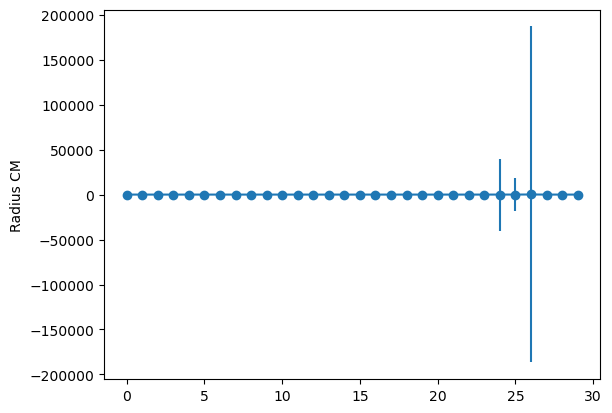

In [84]:
plt.scatter(range(len(bolidelist)), bolidelist)
plt.errorbar(range(len(errorlist)), bolidelist, yerr=errorlist)
plt.ylabel('Radius CM')

Text(0, 0.5, 'Radius CM')

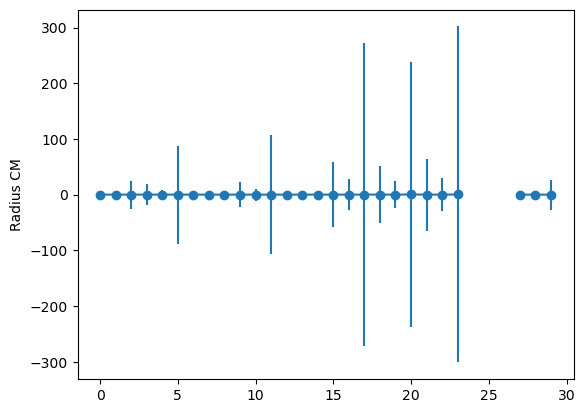

In [85]:
plt.scatter(range(len(bolidelist[:24])), bolidelist[:24]) #second graph removing the outlier bolide
plt.scatter(range(len(bolidelist))[27:], bolidelist[27:], c='C0')
plt.errorbar(range(len(errorlist[:24])), bolidelist[:24], yerr=errorlist[:24])
plt.errorbar(range(len(errorlist))[27:], bolidelist[27:], yerr=errorlist[27:], c='C0')
plt.ylabel('Radius CM')

In [86]:
for i in range(len(bolidelist)):
    print (errorlist[i]/bolidelist[i])

1391.788613347001
1391.7886133470008
1391.788613347001
1856.413178522244
1856.4131785222444
1856.4131785222444
1360.7130948764968
1360.713094876497
1360.713094876497
2166.3803707377315
2166.380370737731
2166.3803707377315
1234.8304303453815
1234.8304303453815
1234.8304303453815
2684.6785105273434
2684.678510527343
2684.678510527343
888.2942280275925
888.2942280275925
888.2942280275925
1155.086774349603
1155.086774349603
1155.086774349603
1663.3437755390055
1663.3437755390057
1663.3437755390055
2546.3307609804197
2546.330760980419
2546.330760980419
